# 01 - MLP NumPy

Etapa 1: MLP puro em NumPy. Este notebook usa PathMNIST 28x28 em grayscale, conforme permitido para a etapa matematica/algoritmica.

In [1]:
import importlib.util
import os
import random
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

def ensure_package(package, import_name=None):
    import_name = import_name or package.split('==')[0].replace('-', '_')
    if importlib.util.find_spec(import_name) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)

if IN_COLAB:
    ensure_package('medmnist==3.0.2', 'medmnist')
    ensure_package('pandas', 'pandas')
    ensure_package('matplotlib', 'matplotlib')

project_candidates = [Path.cwd(), Path.cwd().parent, Path('/content/AP2_IA'), Path('/content/ap2-ia'), Path('/content/drive/MyDrive/AP2_IA')]
PROJECT_ROOT = next((path for path in project_candidates if (path / 'src' / 'numpy_nn' / 'model.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao encontrei a raiz do projeto. Execute o notebook dentro da pasta do repositorio.')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from medmnist import PathMNIST

from numpy_nn.gradient_check import gradient_check
from numpy_nn.model import NumpyMLP
from numpy_nn.optimizers import SGDMomentum
from utils import save_json

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
ARTIFACT_DIR = PROJECT_ROOT / 'experiments' / 'stage01_numpy'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print('Projeto:', PROJECT_ROOT)

Projeto: /content/ap2-ia


In [2]:
train_ds = PathMNIST(split='train', size=28, download=True)
val_ds = PathMNIST(split='val', size=28, download=True)

def prepare_numpy_split(dataset):
    x = dataset.imgs.astype('float64') / 255.0
    x = x.mean(axis=-1).reshape(len(x), -1)
    y = dataset.labels.reshape(-1).astype(int)
    return x, y

x_train, y_train = prepare_numpy_split(train_ds)
x_val, y_val = prepare_numpy_split(val_ds)
print('train:', x_train.shape, y_train.shape)
print('val:', x_val.shape, y_val.shape)

100%|██████████| 205615438/205615438 [04:22<00:00, 784710.39it/s]


Using downloaded and verified file: /root/.medmnist/pathmnist.npz
train: (89996, 784) (89996,)
val: (10004, 784) (10004,)


In [3]:
small_model = NumpyMLP([784, 8, 9], seed=SEED)
max_relative_diff = gradient_check(small_model, x_train[:4], y_train[:4], tolerance=1e-5)
save_json(ARTIFACT_DIR / 'gradient_check.json', {'max_relative_diff': float(max_relative_diff), 'threshold': 1e-5})
print('Gradient check max diff:', max_relative_diff)

Gradient check max diff: 5.8425213696598955e-09


In [4]:
model = NumpyMLP([784, 128, 64, 9], seed=SEED)
optimizer = SGDMomentum(model.params, lr=1e-2, beta=0.9)
batch_size = 128
epochs = 20
history = []

for epoch in range(1, epochs + 1):
    indices = np.random.permutation(len(x_train))
    losses = []
    for start in range(0, len(x_train), batch_size):
        batch = indices[start:start + batch_size]
        loss, grads = model.loss_and_grads(x_train[batch], y_train[batch])
        optimizer.step(model.params, grads)
        losses.append(loss)
    train_acc = float((model.predict(x_train[:5000]) == y_train[:5000]).mean())
    val_acc = float((model.predict(x_val) == y_val).mean())
    row = {'epoch': epoch, 'loss_train': float(np.mean(losses)), 'acc_train_sample': train_acc, 'acc_val': val_acc}
    history.append(row)
    print(row)

history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACT_DIR / 'numpy_mlp_history.csv', index=False)
save_json(ARTIFACT_DIR / 'numpy_mlp_summary.json', {'final_val_acc': float(history_df['acc_val'].iloc[-1]), 'seed': SEED, 'epochs': epochs})
history_df.tail()

{'epoch': 1, 'loss_train': 2.1213760093475313, 'acc_train_sample': 0.1498, 'acc_val': 0.15873650539784087}
{'epoch': 2, 'loss_train': 1.9916327628135087, 'acc_train_sample': 0.3074, 'acc_val': 0.3052778888444622}
{'epoch': 3, 'loss_train': 1.8620185484006584, 'acc_train_sample': 0.3422, 'acc_val': 0.3359656137544982}
{'epoch': 4, 'loss_train': 1.7906189111214168, 'acc_train_sample': 0.3204, 'acc_val': 0.31757297081167535}
{'epoch': 5, 'loss_train': 1.7370715603377571, 'acc_train_sample': 0.2616, 'acc_val': 0.25469812075169934}
{'epoch': 6, 'loss_train': 1.7138933874410638, 'acc_train_sample': 0.3504, 'acc_val': 0.34646141543382647}
{'epoch': 7, 'loss_train': 1.6807724111921254, 'acc_train_sample': 0.319, 'acc_val': 0.31857257097161135}
{'epoch': 8, 'loss_train': 1.6549066303182804, 'acc_train_sample': 0.2674, 'acc_val': 0.273890443822471}
{'epoch': 9, 'loss_train': 1.6545723444627662, 'acc_train_sample': 0.1872, 'acc_val': 0.18652538984406236}
{'epoch': 10, 'loss_train': 1.643329942377

,epoch,loss_train,acc_train_sample,acc_val
15,16,1.612090,0.3876,0.386345
16,17,1.601917,0.2572,0.258796
17,18,1.594177,0.4002,0.399140
18,19,1.603066,0.3202,0.319772
19,20,1.591789,0.4086,0.400140


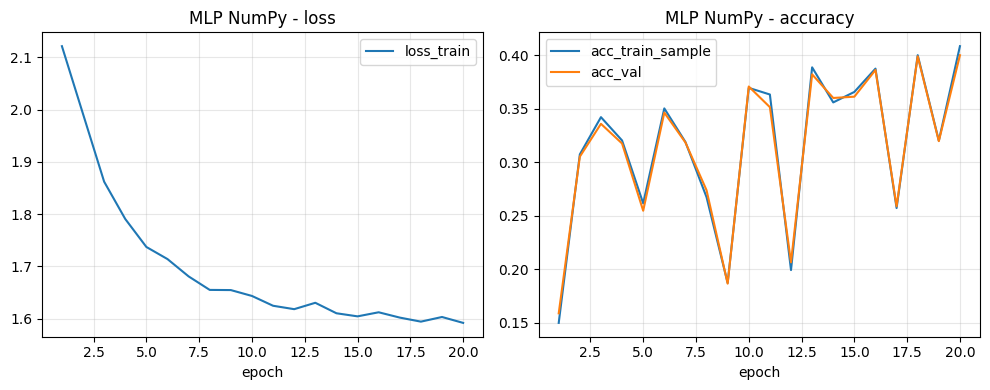

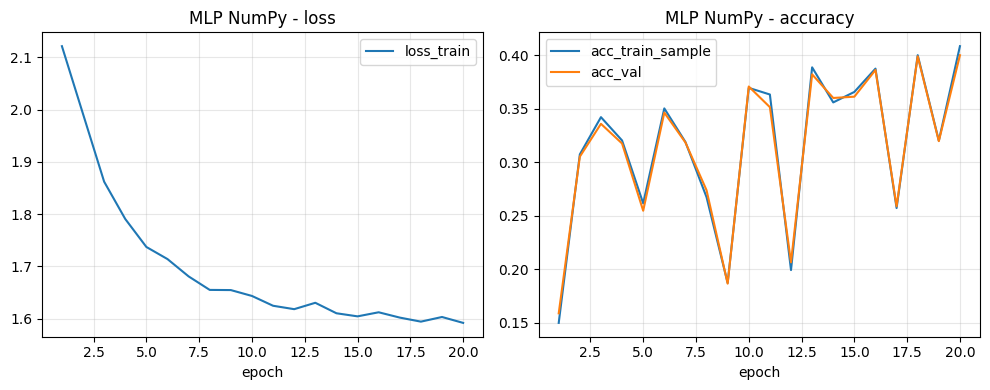

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
history_df.plot(x='epoch', y='loss_train', ax=axes[0], title='MLP NumPy - loss')
history_df.plot(x='epoch', y=['acc_train_sample', 'acc_val'], ax=axes[1], title='MLP NumPy - accuracy')
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'stage01_numpy_curves.png', dpi=160)
fig

Arquivos gerados: `experiments/stage01_numpy/numpy_mlp_history.csv`, `experiments/stage01_numpy/gradient_check.json` e `outputs/figures/stage01_numpy_curves.png`.